In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler #USED FOR STANDARDISIING VALUES
from statsmodels.stats.outliers_influence import variance_inflation_factor # avoiding co linearity

In [ ]:
wdi = pd.read_csv("World development Indicators Data.csv")
column_names_climate = [
    'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N',
    'DJF', 'MAM', 'JJA', 'SON'
]
climate = pd.read_csv("Nasa_climate_data.csv",skiprows=2,sep=',',header=None,names=column_names_climate)
rli = pd.read_csv("red-list-index.csv")
print("WDI shape:", wdi.shape)
print("Climate shape:", climate.shape)
print("RLI shape:", rli.shape)

WDI shape: (95, 29)
Climate shape: (147, 19)
RLI shape: (8320, 4)


In [ ]:
year_cols = [col for col in wdi.columns if "[" in col]
new_year_cols = {col: col.split(" ")[0] for col in year_cols}
wdi = wdi.rename(columns=new_year_cols)#  un clear year column name into normal year
print(wdi.columns[:10])

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000',
       '2001', '2002', '2003', '2004', '2005'],
      dtype='object')


In [ ]:
wdi = wdi.rename(columns={
    "Country Name": "country",
    "Country Code": "country_code",
    "Series Name": "indicator",
    "Series Code": "indicator_code"
})
print(wdi.columns[:10])

Index(['country', 'country_code', 'indicator', 'indicator_code', '2000',
       '2001', '2002', '2003', '2004', '2005'],
      dtype='object')


In [ ]:
wdi_long = wdi.melt(
    id_vars=["country", "country_code", "indicator", "indicator_code"],
    var_name="year",
    value_name="value"
)
print("Long shape:", wdi_long.shape)
wdi_long.head() # melt used for wide format

Long shape: (2375, 6)


,country,country_code,indicator,indicator_code,year,value
0,Brazil,BRA,Agricultural land (% of land area),AG.LND.AGRI.ZS,2000,27.3175012622426
1,Brazil,BRA,Energy use (kg of oil equivalent per capita),EG.USE.PCAP.KG.OE,2000,1081.36193393467
2,Brazil,BRA,Forest area (% of land area),AG.LND.FRST.ZS,2000,65.9343586013156
3,Brazil,BRA,Methane (CH4) emissions from Power Industry (E...,EN.GHG.CH4.PI.MT.CE.AR5,2000,0.0708
4,Brazil,BRA,Nitrous oxide (N2O) emissions from Power Indus...,EN.GHG.N2O.PI.MT.CE.AR5,2000,0.1762


In [ ]:
wdi_long = wdi_long[wdi_long["country"].notna()] #handling nan values
wdi_long = wdi_long[~wdi_long["country"].str.contains("Data from", na=False)] #Not op used like focus on country column and removing meta date update
wdi_long = wdi_long[~wdi_long["country"].str.contains("Last Updated", na=False)]
print("After cleaning:", wdi_long.shape)

After cleaning: (2250, 6)


In [ ]:
wdi_long["year"] = wdi_long["year"].astype(int)
wdi_long["value"] = wdi_long["value"].replace("..", np.nan)
wdi_long["value"] = pd.to_numeric(wdi_long["value"], errors="coerce")
print("Value dtype:", wdi_long["value"].dtype)
print("Total missing:", wdi_long["value"].isna().sum())

Value dtype: float64
Total missing: 774


In [ ]:
wdi_long = wdi_long.sort_values(["country","indicator","year"])
wdi_long = wdi_long.dropna(subset=["value"])
print("After removing missing:", wdi_long.shape)
wdi_long = wdi_long[~wdi_long["indicator"].str.contains("species|threatened", case=False, na=False)]

After removing missing: (1476, 6)


In [ ]:
missing_ratio = wdi_long.groupby("indicator")["value"].apply(lambda series: series.isna().mean())
drop_indicators = missing_ratio[missing_ratio > 0.6].index
wdi_long = wdi_long[~wdi_long["indicator"].isin(drop_indicators)]
print("Remaining indicators:", wdi_long["indicator"].nunique())

Remaining indicators: 11


In [ ]:
print("Total missing after cleaning:", wdi_long["value"].isna().sum())

Total missing after cleaning: 0


In [ ]:
panel = wdi_long.pivot_table(
    index=["country", "year"],
    columns="indicator",
    values="value"
).reset_index()
panel.columns.name = None
panel = panel.loc[:, ~panel.columns.str.contains("species|threatened", case=False)]
print(panel.shape)
panel.head()

(150, 13)


,country,year,Agricultural land (% of land area),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Energy use (kg of oil equivalent per capita),Forest area (% of land area),Fossil fuel energy consumption (% of total),Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",Renewable energy consumption (% of total final energy consumption),Terrestrial and marine protected areas (% of total territorial area),Terrestrial protected areas (% of total land area)
0,Brazil,2000,27.317501,2.007879,1081.361934,65.934359,58.004565,0.0708,0.1762,15.572382,42.7,NaN,NaN
1,Brazil,2001,27.329908,1.992821,1086.992993,65.461671,58.664719,0.0827,0.1874,15.552813,41.3,NaN,NaN
2,Brazil,2002,27.342315,1.968796,1103.401279,64.988983,56.805126,0.0906,0.1628,15.517601,42.9,NaN,NaN
3,Brazil,2003,27.354722,1.918394,1107.973916,64.516295,54.327692,0.1022,0.1767,15.470772,45.1,NaN,NaN
4,Brazil,2004,27.367130,1.999783,1157.169056,64.043608,54.350383,0.1126,0.1917,15.416351,45.2,NaN,NaN


In [ ]:
climate_clean = climate[["Year", "DJF", "MAM", "JJA", "SON"]].copy()
climate_clean["Year"] = pd.to_numeric(climate_clean["Year"], errors="coerce")
climate_clean = climate_clean.dropna(subset=["Year"])
climate_clean["Year"] = climate_clean["Year"].astype(int)
climate_clean.columns = ["year", "temp_winter", "temp_spring", "temp_summer", "temp_autumn"]
panel = panel.merge(climate_clean, on="year", how="left") # added nasa data as a column
print(panel.head())

  country  year  Agricultural land (% of land area)  \
0  Brazil  2000                           27.317501   
1  Brazil  2001                           27.329908   
2  Brazil  2002                           27.342315   
3  Brazil  2003                           27.354722   
4  Brazil  2004                           27.367130   

   Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  \
0                                           2.007879                            
1                                           1.992821                            
2                                           1.968796                            
3                                           1.918394                            
4                                           1.999783                            

   Energy use (kg of oil equivalent per capita)  Forest area (% of land area)  \
0                                   1081.361934                     65.934359   
1                   

In [ ]:
numeric_cols = panel.select_dtypes(include=["float64", "int64"]).columns
numeric_cols = [col for col in numeric_cols if col not in ["year"]]
desc_stats = panel[numeric_cols].describe().T
desc_stats["skewness"] = panel[numeric_cols].skew()
desc_stats["kurtosis"] = panel[numeric_cols].kurtosis() #shows characteristics of the dataset
desc_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Agricultural land (% of land area),144.0,51.565701,13.560020,27.317501,46.066858,52.172532,60.430464,73.732071,-0.343678,-0.582793
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),150.0,7.359693,5.411091,0.939790,2.271966,7.295216,9.767403,21.011875,0.801928,-0.143354
Energy use (kg of oil equivalent per capita),144.0,2962.101739,2199.324380,393.380886,1257.194558,2431.969118,3897.263616,8055.145489,0.898407,-0.212253
Forest area (% of land area),144.0,30.974907,15.494155,12.210143,21.729351,28.538322,33.786986,65.934359,0.998868,0.060486
Fossil fuel energy consumption (% of total),144.0,51.324200,38.013283,0.000000,0.000000,70.498533,84.141320,91.424732,-0.501813,-1.584743
Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),150.0,0.838625,0.848019,0.070800,0.262075,0.422800,1.458325,4.135000,1.716859,3.006040
Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),150.0,10.856747,14.258451,0.162800,0.671075,4.196800,15.960575,64.794300,1.890766,3.505914
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",126.0,27.254663,21.397328,7.176021,12.126209,15.387358,49.578701,79.037396,0.932966,-0.722150
Renewable energy consumption (% of total final energy consumption),132.0,20.714394,16.132870,0.800000,7.700000,13.600000,36.125000,50.000000,0.561963,-1.298864
Terrestrial and marine protected areas (% of total territorial area),72.0,22.186111,12.279335,3.400000,14.700000,20.400000,29.425000,42.100000,0.048099,-1.144636


In [ ]:
pressure_cols = [
    "Forest area (% of land area)",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)",
    "Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e)",
    "PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",
    "Terrestrial and marine protected areas (% of total territorial area)",
    "temp_winter",
    "temp_spring",
    "temp_summer",
    "temp_autumn"
]


In [ ]:
pressure_cols = [col for col in panel.columns if col not in ["country", "year"]]
X_pressure = panel[pressure_cols].dropna()
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pressure)
# VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_pressure.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]
vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

,feature,VIF
0,Energy use (kg of oil equivalent per capita),1144.375450
1,Carbon dioxide (CO2) emissions excluding LULUC...,1102.628676
2,Forest area (% of land area),701.231598
3,Agricultural land (% of land area),623.892924
4,Nitrous oxide (N2O) emissions from Power Indus...,325.036056
5,Methane (CH4) emissions from Power Industry (E...,241.289018
6,Terrestrial protected areas (% of total land a...,72.631519
7,Renewable energy consumption (% of total final...,71.690402
8,"PM2.5 air pollution, mean annual exposure (mic...",61.988774
9,temp_spring,13.632028


In [ ]:
rli = rli.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Red List Index": "rli" #  column name renamed
})
rli = rli[["country", "year", "rli"]]
rli["year"] = pd.to_numeric(rli["year"], errors="coerce")
rli["rli"] = pd.to_numeric(rli["rli"], errors="coerce")
rli = rli.dropna()
print(rli.head())
print("RLI shape:", rli.shape)

       country  year   rli
0  Afghanistan  1993  0.93
1  Afghanistan  1994  0.93
2  Afghanistan  1995  0.93
3  Afghanistan  1996  0.93
4  Afghanistan  1997  0.93
RLI shape: (8320, 3)


In [ ]:
panel_full = panel.merge(rli, on=["country", "year"], how="inner")
print("Merged dataset shape:", panel_full.shape)
panel_full.head()

Merged dataset shape: (150, 18)


,country,year,Agricultural land (% of land area),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Energy use (kg of oil equivalent per capita),Forest area (% of land area),Fossil fuel energy consumption (% of total),Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",Renewable energy consumption (% of total final energy consumption),Terrestrial and marine protected areas (% of total territorial area),Terrestrial protected areas (% of total land area),temp_winter,temp_spring,temp_summer,temp_autumn,rli
0,Brazil,2000,27.317501,2.007879,1081.361934,65.934359,58.004565,0.0708,0.1762,15.572382,42.7,NaN,NaN,.40,.49,.40,.32,0.9
1,Brazil,2001,27.329908,1.992821,1086.992993,65.461671,58.664719,0.0827,0.1874,15.552813,41.3,NaN,NaN,.39,.54,.53,.58,0.9
2,Brazil,2002,27.342315,1.968796,1103.401279,64.988983,56.805126,0.0906,0.1628,15.517601,42.9,NaN,NaN,.70,.70,.56,.59,0.9
3,Brazil,2003,27.354722,1.918394,1107.973916,64.516295,54.327692,0.1022,0.1767,15.470772,45.1,NaN,NaN,.59,.59,.57,.62,0.9
4,Brazil,2004,27.367130,1.999783,1157.169056,64.043608,54.350383,0.1126,0.1917,15.416351,45.2,NaN,NaN,.68,.54,.39,.61,0.9


In [ ]:
panel_full.isna().sum()

,0
country,0
year,0
Agricultural land (% of land area),6
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),0
Energy use (kg of oil equivalent per capita),6
Forest area (% of land area),6
Fossil fuel energy consumption (% of total),6
Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),0
Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),0
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",24


In [ ]:
panel_full = panel_full.drop(columns=[
"Terrestrial and marine protected areas (% of total territorial area)",
"Terrestrial protected areas (% of total land area)"
])

In [ ]:
panel_full = panel_full.dropna()

In [ ]:
panel_full.isna().sum()

,0
country,0
year,0
Agricultural land (% of land area),0
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),0
Energy use (kg of oil equivalent per capita),0
Forest area (% of land area),0
Fossil fuel energy consumption (% of total),0
Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),0
Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),0
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",0


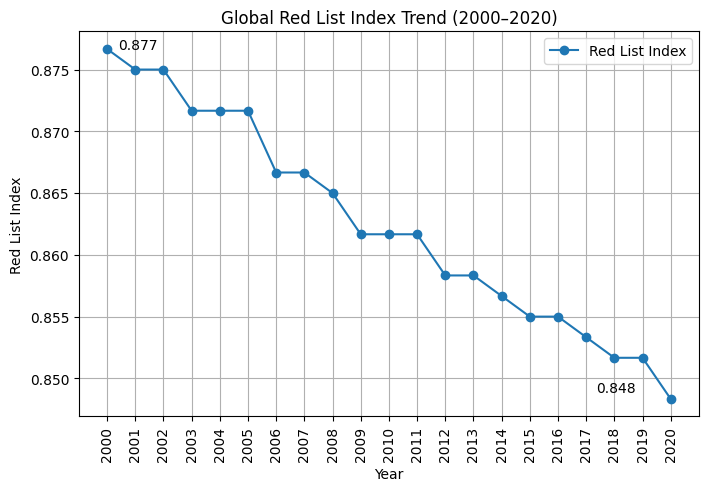

In [ ]:
import matplotlib.pyplot as plt
rli_trend = panel_full.groupby("year")["rli"].mean()
plt.figure(figsize=(8,5))
plt.plot(rli_trend.index, rli_trend.values, marker='o', label="Red List Index")
plt.xticks(list(rli_trend.index), rotation=90)
plt.annotate(f"{rli_trend.iloc[0]:.3f}",
             (rli_trend.index[0], rli_trend.iloc[0]),
             textcoords="offset points",
             xytext=(8,0),
             ha='left')
plt.annotate(f"{rli_trend.iloc[-1]:.3f}",
             (rli_trend.index[-1], rli_trend.iloc[-1]),
             textcoords="offset points",
             xytext=(-25,5),
             ha='right')
plt.title("Global Red List Index Trend (2000–2020)")
plt.xlabel("Year")
plt.ylabel("Red List Index")
plt.legend()
plt.grid(True)
plt.show()

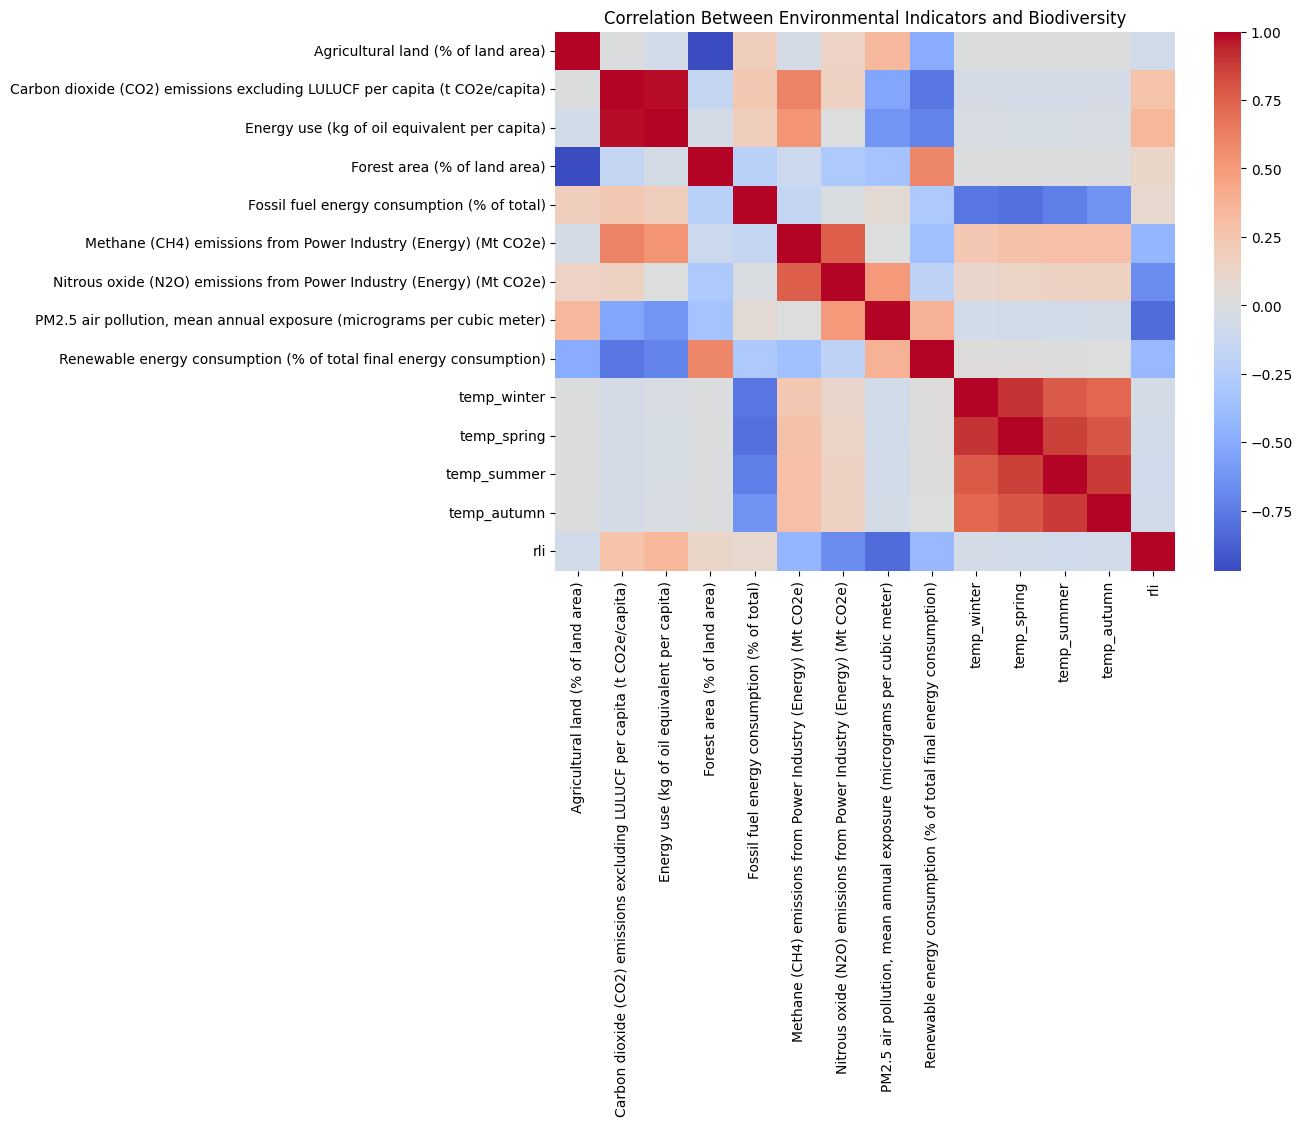

In [ ]:
import seaborn as sns # CORELATION HEAT MAP
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
corr = panel_full.drop(columns=["country","year"]).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Between Environmental Indicators and Biodiversity")
plt.show()

In [ ]:
panel_full["country"].unique()[:20]

array(['Brazil', 'China', 'Germany', 'India', 'United Kingdom',
       'United States'], dtype=object)

In [ ]:
selected_countries = ["Brazil", "China", "Germany", "India", "United Kingdom", "United States"]
panel_filtered = panel_full[panel_full["country"].isin(selected_countries)]
print(panel_filtered.shape)

(126, 16)


In [ ]:
panel_filtered = panel_filtered[(panel_filtered["year"] >= 2000) & (panel_filtered["year"] <= 2020)]
print(panel_filtered.shape)

(126, 16)


In [ ]:
panel_filtered = panel_filtered.dropna()
print(panel_filtered.shape)
drop_cols = [
    "Energy use (kg of oil equivalent per capita)",
    "Agricultural land (% of land area)",
    "Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e)"
]
panel_filtered = panel_filtered.drop(columns=drop_cols, errors='ignore')
print("After dropping high VIF columns:", panel_filtered.shape)

(126, 16)
After dropping high VIF columns: (126, 13)


In [ ]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
feature_cols = [col for col in panel_filtered.columns if col not in ["country", "year", "rli"]]
X_vif = panel_filtered[feature_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)
# calculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = feature_cols
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
print(vif_data)

                                             feature       VIF
0                                        temp_spring  9.610321
1  Renewable energy consumption (% of total final...  9.603699
2  Carbon dioxide (CO2) emissions excluding LULUC...  8.707956
3                                        temp_summer  7.229077
4                                        temp_winter  6.046282
5  PM2.5 air pollution, mean annual exposure (mic...  5.518665
6                       Forest area (% of land area)  5.517880
7                                        temp_autumn  4.720837
8        Fossil fuel energy consumption (% of total)  4.345783
9  Methane (CH4) emissions from Power Industry (E...  4.294922


In [ ]:
panel_filtered[["country", "year", "rli"]].head()
panel_filtered[["country", "year", "rli"]].tail()

,country,year,rli
141,United States,2016,0.84
142,United States,2017,0.84
143,United States,2018,0.84
144,United States,2019,0.84
145,United States,2020,0.83


In [ ]:
import plotly.express as a
Latestdata = panel_filtered[panel_filtered["year"] == 2020]
RLIglobe = a.choropleth(
    Latestdata,
    locations="country",
    locationmode="country names",
    color="rli",
    hover_name="country",
    projection="orthographic",
    title="3D Globe View of Biodiversity (RLI - 2020)",
    color_continuous_scale="Viridis"
)
RLIglobe.update_layout(
    geo=dict(
        showcoastlines=True,
        showland=True,
        landcolor="lightgray"
    )
)
RLIglobe.show()

In [ ]:
from sklearn.model_selection import train_test_split
X = panel_filtered.drop(columns=["country", "year", "rli"])
y = panel_filtered["rli"]
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (75, 10)
Validation: (25, 10)
Test: (26, 10)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
test_pred_lr = lr.predict(X_test_scaled)
lr_r2 = r2_score(y_test, test_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, test_pred_lr))
print("Linear Regression R2:", lr_r2)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression R2: 0.959322059792304
Linear Regression RMSE: 0.020740666217437705


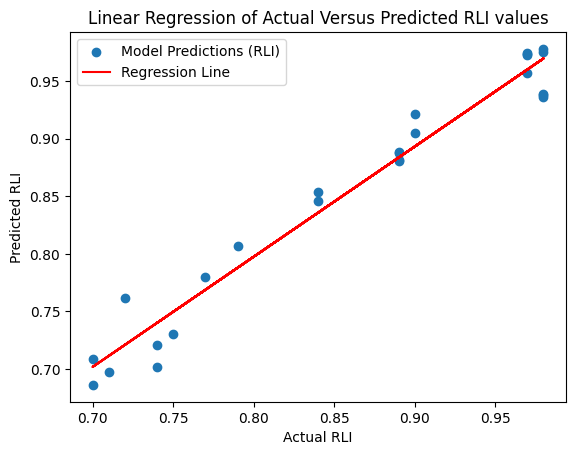

In [ ]:
plt.figure()
plt.scatter(y_test, test_pred_lr, label="Model Predictions (RLI)")
m, b = np.polyfit(y_test, test_pred_lr, 1)
plt.plot(y_test, m*y_test + b, color='red', label="Regression Line")
plt.xlabel("Actual RLI")
plt.ylabel("Predicted RLI")
plt.title("Linear Regression of Actual Versus Predicted RLI values")
plt.legend()
plt.show()

Random Forest Validation R2: 0.9983051156271899
Random Forest Validation RMSE: 0.0043987270886018245
Random Forest Test R2: 0.9985270073299015
Random Forest Test RMSE: 0.00394678544952922


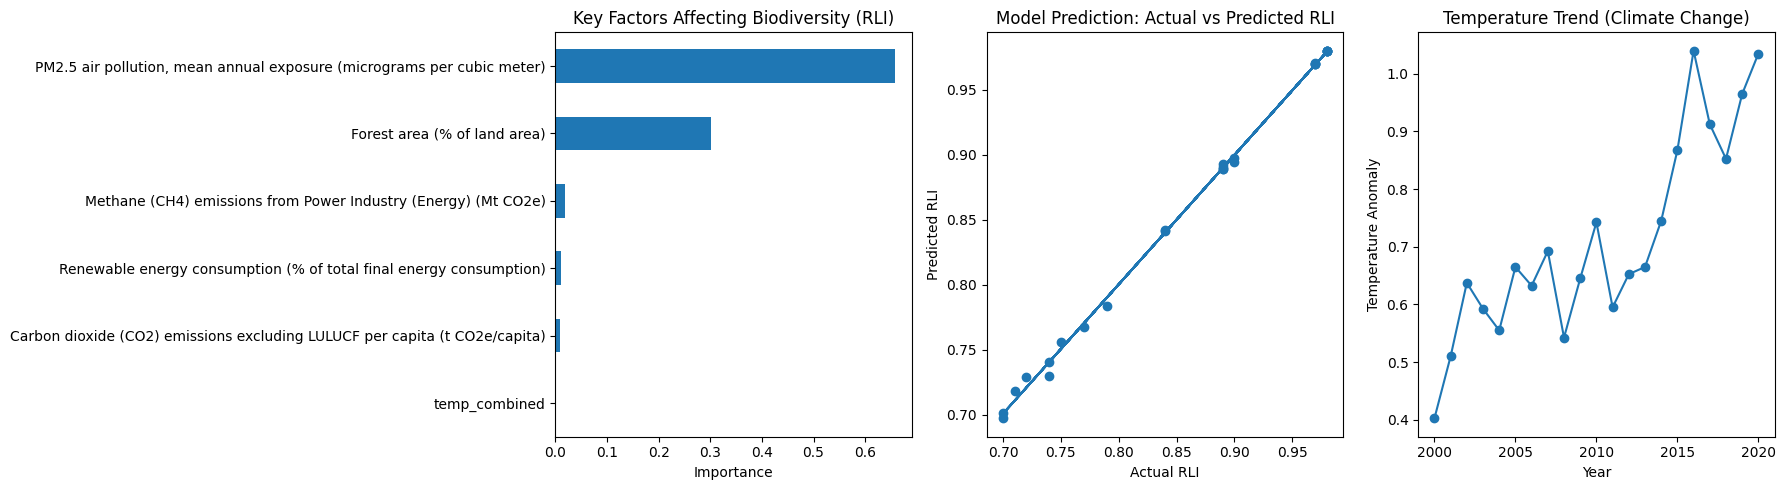

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
temp_cols = ["temp_winter", "temp_spring", "temp_summer", "temp_autumn"]
for col in temp_cols:
    panel_filtered[col] = pd.to_numeric(panel_filtered[col], errors="coerce")
panel_filtered = panel_filtered.dropna(subset=temp_cols)
panel_filtered["temp_combined"] = (
    panel_filtered["temp_winter"] +
    panel_filtered["temp_spring"] +
    panel_filtered["temp_summer"] +
    panel_filtered["temp_autumn"]
) / 4
X = panel_filtered.drop(columns=["country", "year", "rli"])
y = panel_filtered["rli"]
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
val_pred_rf = rf.predict(X_val_scaled)
rf_r2 = r2_score(y_val, val_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_val, val_pred_rf))
print("Random Forest Validation R2:", rf_r2)
print("Random Forest Validation RMSE:", rf_rmse)
test_pred_rf = rf.predict(X_test_scaled)
rf_test_r2 = r2_score(y_test, test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_rf))
print("Random Forest Test R2:", rf_test_r2)
print("Random Forest Test RMSE:", rf_test_rmse)
fig, axes = plt.subplots(1, 3, figsize=(18,5),dpi=300)
# 1. Feature Importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(5)
if "temp_combined" in importance.index:
    top_features["temp_combined"] = importance["temp_combined"]
top_features.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Key Factors Affecting Biodiversity (RLI)")
axes[0].set_xlabel("Importance")
# 2. Actual vs Predicted (IMPORTANT)
test_pred_rf = rf.predict(X_test_scaled)
axes[1].scatter(y_test, test_pred_rf)
m, b = np.polyfit(y_test, test_pred_rf, 1)
axes[1].plot(y_test, m*y_test + b)
axes[1].set_title("Model Prediction: Actual vs Predicted RLI")
axes[1].set_xlabel("Actual RLI")
axes[1].set_ylabel("Predicted RLI")
# 3. Temperature Trend
temp_trend = panel_filtered.groupby("year")["temp_combined"].mean().reset_index()
temp_trend = temp_trend.sort_values("year")
axes[2].plot(temp_trend["year"], temp_trend["temp_combined"], marker='o')
axes[2].set_title("Temperature Trend (Climate Change)")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Temperature Anomaly")
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
# GRADIENT BOOSTING
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train_scaled, y_train)
val_pred_gb = gb.predict(X_val_scaled) #validation
gb_r2 = r2_score(y_val, val_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_val, val_pred_gb))
print("Gradient Boost Validation R2:", gb_r2)
print("Gradient Boost Validation RMSE:", gb_rmse)
test_pred_gb = gb.predict(X_test_scaled)  #testing
gb_test_r2 = r2_score(y_test, test_pred_gb)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_gb))
print("Gradient Boost Test R2:", gb_test_r2)
print("Gradient Boost Test RMSE:", gb_test_rmse)
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(gb, X_train_scaled, y_train, cv=5, scoring='r2')
print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

Gradient Boost Validation R2: 0.997976565799938
Gradient Boost Validation RMSE: 0.0048061965032557274
Gradient Boost Test R2: 0.9986133101101853
Gradient Boost Test RMSE: 0.003829419109529665
Cross Validation R2 Scores: [0.99399333 0.99733416 0.99825829 0.97732275 0.99402302]
Mean CV R2: 0.9921863093500457


In [ ]:
from sklearn.neural_network import MLPRegressor
ann = MLPRegressor(
    hidden_layer_sizes=(32,),
    activation='relu',
    solver='adam',
    max_iter=500,
    alpha=0.01,                # regularization
    learning_rate_init=0.001,
    random_state=42
)
ann.fit(X_train_scaled, y_train)
# VALIDATION
val_pred_ann = ann.predict(X_val_scaled)
ann_r2 = r2_score(y_val, val_pred_ann)
ann_rmse = np.sqrt(mean_squared_error(y_val, val_pred_ann))
print("ANN Validation R2:", ann_r2)
print("ANN Validation RMSE:", ann_rmse)
test_pred_ann = ann.predict(X_test_scaled)
ann_test_r2 = r2_score(y_test, test_pred_ann)
ann_test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_ann))
print("ANN Test R2:", ann_test_r2)
print("ANN Test RMSE:", ann_test_rmse)

ANN Validation R2: -0.516028618284893
ANN Validation RMSE: 0.13155600596833403
ANN Test R2: -1.3655169375590916
ANN Test RMSE: 0.15816349624116322


               Model  Validation R2   Test R2  Test RMSE
0  Linear Regression       0.959322  0.959322   0.020741
1      Random Forest       0.998305  0.998527   0.003947
2     Gradient Boost       0.997977  0.998613   0.003829
3                ANN      -0.516029 -1.365517   0.158163


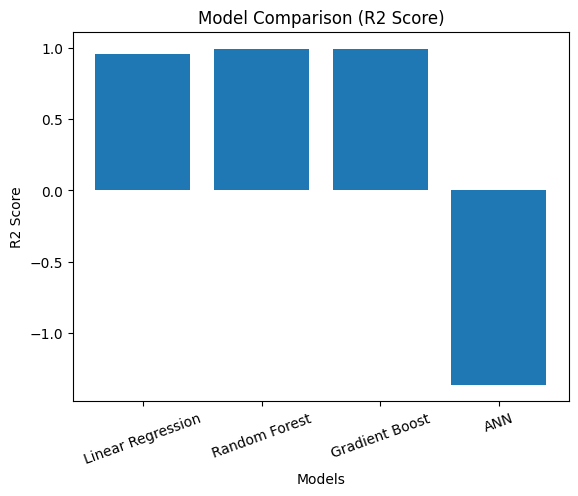

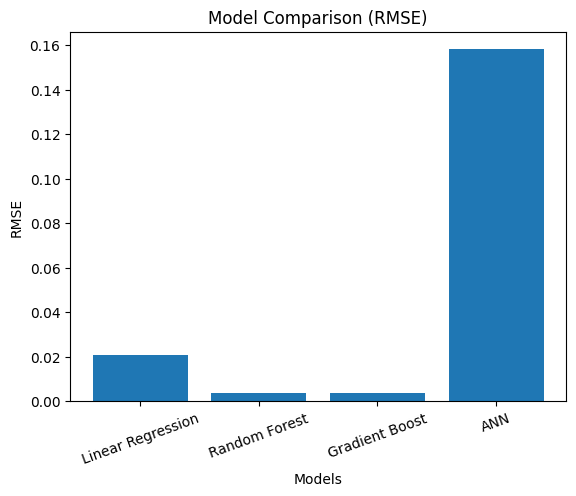

In [ ]:
import pandas as pd
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boost", "ANN"],
    "Validation R2": [lr_r2, rf_r2, gb_r2, ann_r2],
    "Test R2": [r2_score(y_test, test_pred_lr), rf_test_r2, gb_test_r2, ann_test_r2],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, test_pred_lr)),
        rf_test_rmse,
        gb_test_rmse,
        ann_test_rmse
    ]
})
print(results)
plt.figure()
plt.bar(results["Model"], results["Test R2"])
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xlabel("Models")
plt.xticks(rotation=20)
plt.show()
plt.figure()
plt.bar(results["Model"], results["Test RMSE"])
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Models")
plt.xticks(rotation=20)
plt.show()